__Задача 3__: Разработка системы детектирования объектов на основе нейронной сети you-only-look-once (YOLO)

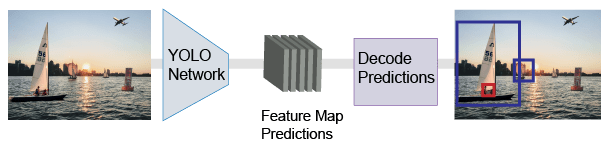

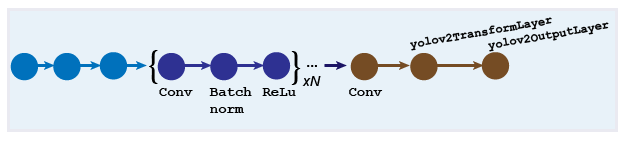

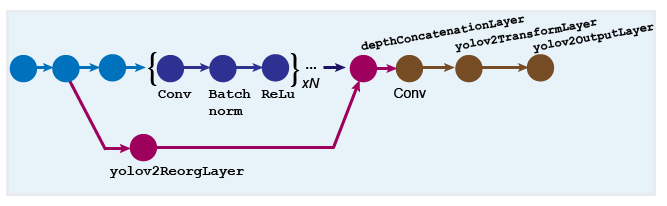

---

In [1]:
import os
import pandas as pd
import numpy as np
from numpy import random as rng
from PIL import Image
from PIL import ImageDraw
from matplotlib import pyplot as plt

## данные 

In [2]:
# !ls ../data/vehicleImages

In [3]:
folder_img = '../data/vehicleImages' # папка с картинками для распознавания
folder_result = 'result/lab_03/' # папка с картинками размеченными моделью

In [4]:
# список файлов с картинками
files = [ f for f in os.listdir(folder_img) if f[-4:]=='.jpg' ]
display(len(files))

295

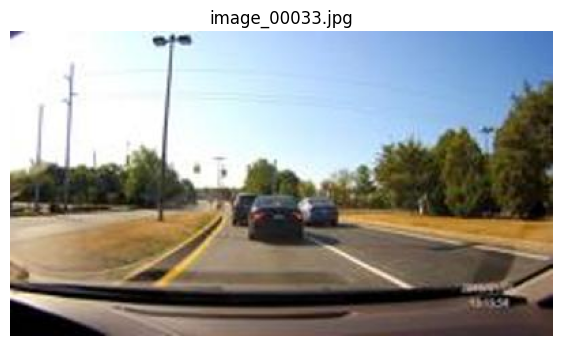

In [5]:
f = rng.permutation(files)[0]
plt.figure(figsize=(7,5))
plt.axis(False)
plt.title(f)
plt.imshow( np.array(Image.open(folder_img+'/'+f)) )

## подгружаем предобученую модель  YOLO

In [6]:
# !pip install opencv-python
# !pip install ultralytics
# !pip install smmap gitdb gitpython

In [7]:
import torch
# import torchvision
# from torchvision import transforms

In [8]:
model = torch.hub.load('ultralytics/yolov5', 'yolov5s', pretrained=True)

Using cache found in /home/mechanoid/.cache/torch/hub/ultralytics_yolov5_master
YOLOv5 🚀 2023-5-31 Python-3.9.16 torch-2.0.1+cu117 CUDA:0 (NVIDIA GeForce GTX 1060 6GB, 6070MiB)

Fusing layers... 
YOLOv5s summary: 213 layers, 7225885 parameters, 0 gradients
Adding AutoShape... 


In [23]:
# model

## выполняем детекцию

In [10]:
def proc_file( f, folder_img=folder_img, folder_result=folder_result ):
    img = Image.open(folder_img+'/'+f ) # загружаем картинку
    df = model(img).pandas().xyxy[0] # распознаём

    boxes  = df[['xmin','ymin','xmax','ymax']].values
    scores = df['confidence'].tolist()
    labels = df['name'].tolist()

    res = img.copy()
    res_draw = ImageDraw.Draw(res)

    for n in range(len(labels)): # для всех найденых объектов
        fx0,fy0,fx1,fy1 = boxes[n,:].tolist() # координаты углов рамки объекта
        res_draw.rectangle( (fx0,fy0,fx1,fy1), outline='red' ) # рисуем рамку
        # подписываем
        tfp = fx0,fy0-10,fx1,fy0   # координаты рамки заголовка
        res_draw.rectangle(tfp,fill='red')
        tx,ty = fx0,fy0-10 # координаты подписи
        text = '%s %.2f'%(labels[n],scores[n])
        res_draw.text((tx,ty),text,fill='white')    
       
    res.save(folder_result+'/'+f)
    df.to_csv(folder_result+'/'+f[:-4]+'.tsv',index=False,sep='\t')
    
    del img
    del res_draw
    del res    

In [11]:
from tqdm.auto import tqdm

for f in tqdm(files): proc_file(f)

  0%|          | 0/295 [00:00<?, ?it/s]

## результаты 

![img](result/lab_03/image_00035.jpg)
![img](result/lab_03/image_00085.jpg)
![img](result/lab_03/image_00075.jpg)

![img](result/lab_03/image_00128.jpg)
![img](result/lab_03/image_00143.jpg)

![img](result/lab_03/image_00175.jpg)